# Sentiment Analysis — PyTorch BiLSTM

> **Before running:** Runtime → Change runtime type → **T4 GPU**

| Step | Content |
|------|---------|
| 1 | Config — all hyperparameters in one cell |
| 2 | Dataset — IMDb 50 000 reviews, auto-downloaded |
| 3 | Preprocessing — clean, tokenise, pad |
| 4 | Model — Bidirectional LSTM |
| 5 | Training — early stopping, LR scheduler |
| 6 | Evaluation — accuracy, F1, confusion matrix |
| 7 | Prediction — run on your own text |
| 8 | Download — save model files for local use |

**Expected test accuracy: ~90-92%** — each epoch takes ~25 s on T4 GPU.

In [2]:
!pip install -q datasets

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU')

PyTorch : 2.11.0+cu128
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB


In [3]:
import re
import pickle
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from datasets import load_dataset

print('Imports OK.')

Imports OK.


## 1 — Configuration

All hyperparameters live here. Change a value and re-run — no other cells need editing.

> **Local use**: the local project reads these same values from a `.env` file so you never have to touch `config.py`.

In [4]:
# Vocabulary & sequence
MAX_VOCAB_SIZE = 25_000
MAX_SEQ_LEN    = 256

# Model
EMBED_DIM   = 128
HIDDEN_DIM  = 256
N_LAYERS    = 2
DROPOUT     = 0.3
NUM_CLASSES = 2     # 2 = pos/neg  |  3 = pos/neu/neg (needs tweet_eval dataset)

# Training
BATCH_SIZE    = 64
EPOCHS        = 10
LEARNING_RATE = 1e-3

print('Config ready.')

Config ready.


## 2 — Dataset

**IMDb Movie Reviews** — 25 000 train + 25 000 test, labels: 0 = negative, 1 = positive.

Downloaded once and cached automatically by HuggingFace (~80 MB).

**Want 3-class (positive / neutral / negative)?**  
Set `NUM_CLASSES = 3` above and replace the cell below with:
```python
dataset   = load_dataset('tweet_eval', 'sentiment')  # 0=neg 1=neu 2=pos
train_raw = dataset['train']
test_raw  = dataset['test']
```

In [5]:
print('Downloading IMDb dataset...')
dataset   = load_dataset('stanfordnlp/imdb')
train_raw = dataset['train']
test_raw  = dataset['test']
print(f'Train: {len(train_raw):,}  |  Test: {len(test_raw):,}')

pos = next(x for x in train_raw if x['label'] == 1)
neg = next(x for x in train_raw if x['label'] == 0)
print('\nPositive sample:', pos['text'][:300])
print('\nNegative sample:', neg['text'][:300])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: 25,000  |  Test: 25,000

Positive sample: Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more strik

Negative sample: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


## 3 — Preprocessing

**Pipeline:**
1. `clean_text` — lowercase, strip HTML `<br />`, remove URLs and punctuation
2. `Vocabulary` — maps each unique word to an integer index (built from training data only)
3. `SentimentDataset` — encodes + pads every review once at startup

**Why pad?**  
Neural networks process batches — all sequences in a batch must be the same length.  
We pad short reviews with zeros and tell the LSTM to skip those positions (`pack_padded_sequence`).

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)               # strip HTML  <br />
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text) # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)              # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

demos = [
    'The movie was <br/>absolutely FANTASTIC! :-) 10/10',
    'Check http://example.com -- terrible acting!!!',
]
for d in demos:
    print('Before:', d)
    print('After :', clean_text(d))
    print()

Before: The movie was <br/>absolutely FANTASTIC! :-) 10/10
After : the movie was absolutely fantastic

Before: Check http://example.com -- terrible acting!!!
After : check terrible acting



In [7]:
class Vocabulary:
    """
    Word → integer index mapping.
    0 = <PAD>  (padding, model ignores these)
    1 = <UNK>  (out-of-vocabulary words at inference time)
    """
    def __init__(self, max_size=25_000):
        self.max_size = max_size
        self.word2idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx2word = {0: '<PAD>', 1: '<UNK>'}

    def build(self, texts):
        counter = Counter(w for t in texts for w in t.split())
        for word, _ in counter.most_common(self.max_size - 2):
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx]  = word

    def encode(self, text, max_len):
        tokens = text.split()[:max_len]
        ids    = [self.word2idx.get(t, 1) for t in tokens]
        length = max(len(ids), 1)            # minimum 1 (LSTM requires > 0)
        ids   += [0] * (max_len - len(ids))  # right-pad
        return ids, length

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump(self, f)

    @staticmethod
    def load(path):
        with open(path, 'rb') as f:
            return pickle.load(f)

    def __len__(self):
        return len(self.word2idx)


class SentimentDataset(Dataset):
    """Encodes all text at construction time — fast batch loading."""
    def __init__(self, texts, labels, vocab, max_len):
        self.samples = []
        for text, label in zip(texts, labels):
            ids, length = vocab.encode(clean_text(text), max_len)
            self.samples.append((
                torch.tensor(ids, dtype=torch.long), length, int(label)
            ))

    def __len__(self):          return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

print('Vocabulary and SentimentDataset defined.')

Vocabulary and SentimentDataset defined.


In [8]:
# Build vocab on TRAINING TEXT ONLY — never use test text here (data leakage)
vocab = Vocabulary(MAX_VOCAB_SIZE)
print('Building vocabulary...')
vocab.build([clean_text(t) for t in train_raw['text']])
print(f'Vocabulary size: {len(vocab):,}')

# Save immediately — needed for local inference later
vocab.save('vocab.pkl')
print('Vocabulary saved to vocab.pkl')

# Encode all 50 000 reviews (~1 min)
print('\nEncoding training set...')
train_ds = SentimentDataset(train_raw['text'], train_raw['label'], vocab, MAX_SEQ_LEN)
print('Encoding test set...')
test_ds  = SentimentDataset(test_raw['text'],  test_raw['label'],  vocab, MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f'\nTrain batches: {len(train_loader)}  |  Test batches: {len(test_loader)}')

ids_b, lens_b, labs_b = next(iter(train_loader))
print(f'Batch shapes — ids: {list(ids_b.shape)}, labels: {labs_b[:6].tolist()}')

Building vocabulary...
Vocabulary size: 25,000
Vocabulary saved to vocab.pkl

Encoding training set...
Encoding test set...

Train batches: 391  |  Test batches: 391
Batch shapes — ids: [64, 256], labels: [1, 1, 1, 1, 0, 1]


## 4 — Model: Bidirectional LSTM

**Why BiLSTM?**
A regular LSTM reads left → right. A BiLSTM also reads right → left, then concatenates both final states. This helps with negation: *"not at all good"* — the backward pass connects *not* to *good* even when they are far apart.

**Architecture:**
```
text (batch, 256)
  → Embedding (batch, 256, 128)   word vectors
  → Dropout
  → BiLSTM ×2                    hidden: (4, batch, 256)
  → concat top fwd + bwd          (batch, 512)
  → Dropout
  → Linear 512 → 2               class logits
```

In [9]:
class SentimentBiLSTM(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim,
                 n_layers, dropout, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers, bidirectional=True,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        self.fc      = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text, lengths):
        embedded = self.dropout(self.embedding(text))
        packed   = pack_padded_sequence(embedded, lengths.cpu(),
                                        batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)  # top fwd + bwd
        return self.fc(self.dropout(hidden))


model = SentimentBiLSTM(
    vocab_size=len(vocab), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    output_dim=NUM_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')
print(model)

Trainable parameters: 5,568,514
SentimentBiLSTM(
  (embedding): Embedding(25000, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=512, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


## 5 — Training

| Technique | Purpose |
|-----------|--------|
| `CrossEntropyLoss` | Loss function for multi-class classification |
| `Adam` + `weight_decay` | Optimizer with built-in L2 regularisation |
| `clip_grad_norm_` | Prevents exploding gradients (common in RNNs) |
| `ReduceLROnPlateau` | Halves learning rate when val loss stops improving |
| Early stopping | Stops training and restores best weights after 3 bad epochs |

In [10]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for ids, lengths, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(ids, lengths)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for ids, lengths, labels in loader:
            ids, labels = ids.to(device), labels.to(device)
            logits = model(ids, lengths)
            loss   = criterion(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total

print('train_epoch / eval_epoch defined.')

train_epoch / eval_epoch defined.


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5
)

best_val_loss    = float('inf')
patience_counter = 0
history          = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f'Training on {device} — up to {EPOCHS} epochs, early stopping patience=3\n')
print('Epoch  Train Loss  Train Acc   Val Loss   Val Acc     LR')
print('-' * 65)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, test_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    lr = optimizer.param_groups[0]['lr']
    marker = ' <-- best' if vl_loss < best_val_loss else ''
    print(f'{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {vl_loss:>9.4f}  {vl_acc:>8.4f}  {lr:.0e}{marker}')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), 'best_model.pth')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 3:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

model.load_state_dict(torch.load('best_model.pth', map_location=device))
print(f'\nBest val loss: {best_val_loss:.4f} — best weights restored.')

Training on cuda — up to 10 epochs, early stopping patience=3

Epoch  Train Loss  Train Acc   Val Loss   Val Acc     LR
-----------------------------------------------------------------
    1      0.6591     0.6069     0.5951    0.6838  1e-03 <-- best
    2      0.6527     0.6285     0.5879    0.6976  1e-03 <-- best
    3      0.5661     0.7086     0.4903    0.7668  1e-03 <-- best
    4      0.4623     0.7868     0.4253    0.8050  1e-03 <-- best
    5      0.4074     0.8236     0.4304    0.8300  1e-03
    6      0.3619     0.8483     0.3367    0.8565  1e-03 <-- best
    7      0.3160     0.8704     0.3252    0.8628  1e-03 <-- best
    8      0.2860     0.8852     0.3185    0.8666  1e-03 <-- best
    9      0.2640     0.8952     0.3195    0.8603  1e-03
   10      0.2445     0.9057     0.3362    0.8628  1e-03

Best val loss: 0.3185 — best weights restored.


### Load from checkpoint (skip training if already trained)

If your Colab session disconnected but you still have `best_model.pth` and `vocab.pkl` in the file browser, run this cell to restore everything without retraining.

In [12]:
import os

if os.path.exists('best_model.pth') and os.path.exists('vocab.pkl'):
    vocab = Vocabulary.load('vocab.pkl')
    model = SentimentBiLSTM(
        vocab_size=len(vocab), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
        output_dim=NUM_CLASSES, n_layers=N_LAYERS, dropout=DROPOUT
    ).to(device)
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    model.eval()
    print('Loaded from checkpoint. Ready to evaluate and predict.')
else:
    print('No checkpoint found — run the Training cells above first.')

Loaded from checkpoint. Ready to evaluate and predict.


## 6 — Evaluation

Evaluate on the **held-out test set** — 25 000 reviews never seen during training.

| Metric | Meaning |
|--------|---------|
| Precision | Of all predicted positives, how many were correct? |
| Recall | Of all actual positives, how many did we find? |
| F1 | Harmonic mean of precision and recall |
| Confusion matrix | Shows which class gets confused with which |

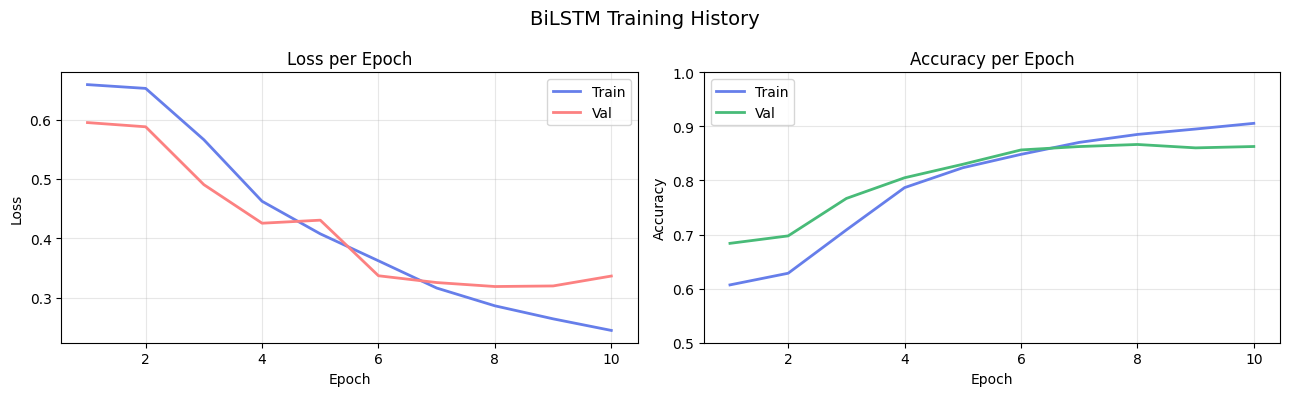

In [13]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_x, history['train_loss'], label='Train', color='#667eea', linewidth=2)
ax1.plot(epochs_x, history['val_loss'],   label='Val',   color='#fc8181', linewidth=2)
ax1.set_title('Loss per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, history['train_acc'], label='Train', color='#667eea', linewidth=2)
ax2.plot(epochs_x, history['val_acc'],   label='Val',   color='#48bb78', linewidth=2)
ax2.set_title('Accuracy per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0.5, 1.0); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('BiLSTM Training History', fontsize=14)
plt.tight_layout(); plt.show()

  CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.8920    0.8342    0.8621     12500
    Positive     0.8443    0.8990    0.8708     12500

    accuracy                         0.8666     25000
   macro avg     0.8681    0.8666    0.8665     25000
weighted avg     0.8681    0.8666    0.8665     25000



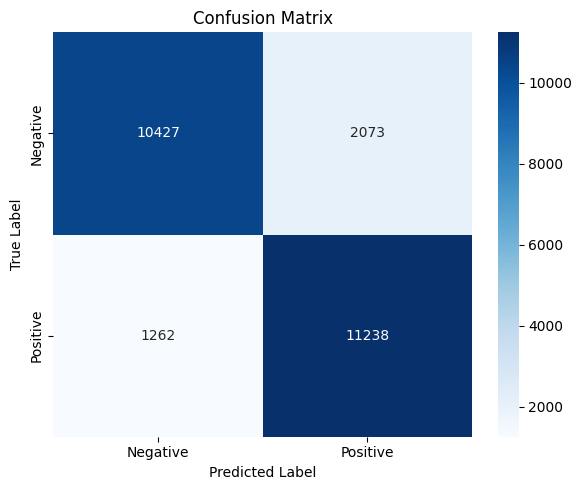

In [14]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for ids, lengths, labels in test_loader:
        preds = model(ids.to(device), lengths).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

classes = ['Negative', 'Positive'] if NUM_CLASSES == 2 else ['Negative', 'Neutral', 'Positive']

print('=' * 52)
print('  CLASSIFICATION REPORT')
print('=' * 52)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title('Confusion Matrix')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## 7 — Prediction

The `predict` function applies the **same cleaning pipeline** as training so the model sees the same token format it was trained on.

In [15]:
import torch.nn.functional as F

LABELS = {0: 'Negative', 1: 'Positive'}
EMOJIS = {'Positive': '\U0001f60a', 'Negative': '\U0001f621', 'Neutral': '\U0001f610'}
if NUM_CLASSES == 3:
    LABELS[2] = 'Neutral'

def predict(text):
    model.eval()
    ids, length = vocab.encode(clean_text(text), MAX_SEQ_LEN)
    ids_t = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        probs = F.softmax(model(ids_t, torch.tensor([length])), dim=1).squeeze()
    pred_idx   = probs.argmax().item()
    confidence = probs[pred_idx].item()
    label      = LABELS[pred_idx]
    return label, EMOJIS[label], confidence


# Batch test
examples = [
    'This movie was absolutely brilliant — one of the best I have ever seen.',
    'Terrible film. Two hours of my life I will never get back.',
    'The cinematography was stunning but the plot made no sense at all.',
    'Started slow but became genuinely gripping by the second act.',
]

print('Text'.ljust(65) + 'Result'.ljust(16) + 'Confidence')
print('-' * 92)
for ex in examples:
    label, emoji, conf = predict(ex)
    short = ex[:61] + '...' if len(ex) > 61 else ex
    print(short.ljust(65) + (emoji + ' ' + label).ljust(16) + f'{conf:.1%}')

Text                                                             Result          Confidence
--------------------------------------------------------------------------------------------
This movie was absolutely brilliant — one of the best I have ... 😊 Positive      99.0%
Terrible film. Two hours of my life I will never get back.       😡 Negative      83.1%
The cinematography was stunning but the plot made no sense at... 😡 Negative      83.1%
Started slow but became genuinely gripping by the second act.    😊 Positive      55.1%


In [16]:
# Try your own text here
your_text = 'The special effects were amazing but the story was completely predictable.'

label, emoji, conf = predict(your_text)
bar = '\u2588' * int(conf * 30) + '\u2591' * (30 - int(conf * 30))
print(f'Text       : {your_text}')
print(f'Sentiment  : {emoji}  {label}')
print(f'Confidence : [{bar}]  {conf:.1%}')

Text       : The special effects were amazing but the story was completely predictable.
Sentiment  : 😡  Negative
Confidence : [█████████████████░░░░░░░░░░░░░]  59.2%


## 8 — Download files for local use

To use the trained model locally (CLI or web app), download both files and place them in your project:

```
best_model.pth  →  model/sentiment_lstm.pth
vocab.pkl       →  model/vocab.pkl
```

Then with the venv activated:
```bash
python predict.py "This movie was great!"
uvicorn app:app --reload --port 8000
```

Config values are read from `.env` — edit that file to change any hyperparameter without touching code.

In [17]:
# Option A — download directly to your computer
from google.colab import files
files.download('best_model.pth')
files.download('vocab.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Option B — save to Google Drive (keeps files between Colab sessions)
from google.colab import drive
import shutil

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/SentimentModel'

import os
os.makedirs(save_dir, exist_ok=True)
shutil.copy('best_model.pth', f'{save_dir}/sentiment_lstm.pth')
shutil.copy('vocab.pkl',      f'{save_dir}/vocab.pkl')
print(f'Saved to {save_dir}')

MessageError: Error: credential propagation was unsuccessful

## Upgrade paths

### 3-class (positive / neutral / negative)
Set `NUM_CLASSES = 3` in Section 1 and load `tweet_eval` instead of IMDb (see Section 2).

### BERT fine-tuning — ~94-96% accuracy
```python
!pip install -q transformers
from transformers import BertTokenizer, BertForSequenceClassification

tokenizer  = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=2
).to(device)
# Tokenise: tokenizer(text, padding='max_length', truncation=True, max_length=256)
# Pass input_ids and attention_mask to bert_model
```

### Zero-shot baseline (no training needed)
```python
from transformers import pipeline
pipe = pipeline('text-classification',
                model='distilbert-base-uncased-finetuned-sst-2-english')
print(pipe('This film was wonderful!'))
```